# ESS 배터리 데이터 탐색

초기 100사이클로 배터리의 **총 수명(`cycle_life`)**을 예측하기 위한 EDA입니다.
다섯 가지 질문을 분석하고, 확인한 내용을 Feature와 모델 설계로 연결합니다.

1. 배치별 수명 분포는 어떻게 다른가요?
2. 방전 용량은 같은 속도로 줄어드나요?
3. 초기 방전 곡선의 차이와 수명은 어떤 관계인가요?
4. 충전 조건에 따라 수명과 초기 용량 기울기가 달라지나요?
5. 수명과 관련이 있거나 서로 중복되는 Feature는 무엇인가요?

**실행 순서:** 이 노트북을 위에서부터 실행한 뒤 `2_ESS-Life.ipynb`에서 모델을 비교합니다.
EDA에는 Batch 1·2·3을 모두 사용합니다. 모델 학습은 이 노트북에서 진행하지 않습니다.

## 준비 | 라이브러리와 데이터 위치

`dataset`에 세 배치의 원본 파일을 준비합니다. 설치 방법은 README에 있습니다.
원본은 읽기 전용으로 사용하고, 표와 그림은 `results/eda`에 저장합니다.
초기 Feature는 모델 노트북과 같은 `battery_features.py`로 계산합니다.

In [1]:
import os
import platform
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from battery_features import (
    BATCH_FILES, FEATURE_COLUMNS, load_feature_table,
    _read_vector, _referenced_object,
)

DATA_DIR = Path(os.environ.get("ESS_DATA_DIR", "dataset")).expanduser()
OUTPUT_DIR = Path("results/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BATCHES = list(BATCH_FILES)
COLORS = {"Batch 1": "#356589", "Batch 2": "#BC7840", "Batch 3": "#77824C"}
MARKERS = {"Batch 1": "o", "Batch 2": "^", "Batch 3": "s"}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "axes.axisbelow": True,
})
pd.set_option("display.max_columns", 14)
pd.set_option("display.precision", 3)

def save_figure(fig, filename):
    fig.savefig(OUTPUT_DIR / filename, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

print(f"Python {platform.python_version()} / pandas {pd.__version__} / numpy {np.__version__}")

Python 3.11.15 / pandas 3.0.6 / numpy 2.4.6


## 데이터 | 배치와 분석 대상 확인

셀 한 개를 표본 한 개로 정리합니다. 수명 분포는 유효 라벨 전체를 사용하고,
Feature 관계는 기존 분석 기준에 따라 B1의 마지막 용량이 0.885 Ah 이하인 셀을 사용합니다.
B2·B3은 양의 수명 라벨이 있는 셀을 사용합니다.

**주의:** 마지막 용량은 미래 정보입니다. 분석군을 정하는 데 사용한 선택 편향이 있으며,
모델의 입력 Feature로는 사용하지 않습니다. 제공된 수명 라벨도 변경하지 않습니다.

In [2]:
source_files = pd.DataFrame([
    {"batch": batch, "file": filename, "exists": (DATA_DIR / filename).is_file()}
    for batch, filename in BATCH_FILES.items()
])
if not source_files["exists"].all():
    missing = source_files.loc[~source_files["exists"], "file"].tolist()
    raise FileNotFoundError(f"dataset에 다음 파일이 필요합니다: {missing}")

features = load_feature_table(DATA_DIR, BATCHES)
valid = features.loc[features["cycle_life"].notna()].copy()
analysis = features.loc[features["main_analysis_eligible"]].copy()

cohort_counts = features.groupby("batch").agg(
    raw_cells=("cell_id", "size"), valid_labels=("cycle_life", "count"),
    analysis_cells=("main_analysis_eligible", "sum"),
    complete_early_cells=("early_100_coverage", "sum"),
)
display(source_files.drop(columns="exists"))
display(cohort_counts)

,batch,file
0,Batch 1,2017-05-12_batchdata_updated_struct_errorcorre...
1,Batch 2,2018-02-20_batchdata_updated_struct_errorcorre...
2,Batch 3,2018-04-12_batchdata_updated_struct_errorcorre...


,raw_cells,valid_labels,analysis_cells,complete_early_cells
batch,,,,
Batch 1,46,46,36,46
Batch 2,47,39,39,47
Batch 3,46,44,44,46


### 곡선과 보조 통계 읽기

HDF5의 참조를 따라 필요한 요약값과 실제 10·100번 사이클의 방전 곡선만 읽습니다.
원본 전체의 분 단위 기록을 한꺼번에 불러오지 않습니다.

In [3]:
def read_summary_details(data_dir, table):
    """전체 용량 곡선, 초기 온도, 충전 시간과 라벨 점검값을 읽습니다."""
    rows, curves, charge_rows = [], {}, []
    for batch_name, group in table.groupby("batch", sort=True):
        with h5py.File(data_dir / BATCH_FILES[batch_name], "r") as file:
            batch = file["batch"]
            for row in group.itertuples(index=False):
                index = int(row.cell_id.split("c")[1])
                summary = _referenced_object(file, batch["summary"], index)
                cycle = _read_vector(summary["cycle"])
                qd = _read_vector(summary["QDischarge"])
                tmax = _read_vector(summary["Tmax"])
                charge = _read_vector(summary["chargetime"])
                if not len(cycle) == len(qd) == len(tmax) == len(charge):
                    raise ValueError(f"요약값 길이가 다릅니다: {row.cell_id}")
                early = (cycle >= 2) & (cycle <= 100)
                times = charge[early].copy()
                times[~np.isfinite(times) | (times <= 0)] = np.nan
                capped_times = times[np.isfinite(times) & (times <= 100)]
                temperatures = tmax[early]
                temperatures = temperatures[np.isfinite(temperatures)]
                crossing = cycle[np.isfinite(qd) & (qd > 0) & (qd < 0.88)]
                rows.append({
                    "cell_id": row.cell_id, "record_count": len(cycle),
                    "first_qd": qd[0],
                    "first_cycle_below_0_88": crossing[0] if len(crossing) else np.nan,
                    "Tmax_mean_2_100": temperatures.mean() if len(temperatures) else np.nan,
                    "chargetime_mean_le100": capped_times.mean() if len(capped_times) else np.nan,
                })
                curves[row.cell_id] = {"cycle": cycle, "qd": qd}
                for cycle_no, value in zip(cycle[early], times):
                    if value > 100:
                        charge_rows.append({"batch": batch_name, "cell_id": row.cell_id,
                                            "cycle": int(cycle_no), "minutes": value})
    charge_columns = ["batch", "cell_id", "cycle", "minutes"]
    return pd.DataFrame(rows), curves, pd.DataFrame(charge_rows, columns=charge_columns)

In [4]:
def read_delta_q_curves(data_dir, table):
    """실제 사이클 번호로 Q100−Q10을 계산하고 공통 전압 격자를 확인합니다."""
    curves, reference_voltage = {}, None
    for batch_name, group in table.groupby("batch", sort=True):
        with h5py.File(data_dir / BATCH_FILES[batch_name], "r") as file:
            batch = file["batch"]
            for row in group.itertuples(index=False):
                index = int(row.cell_id.split("c")[1])
                summary = _referenced_object(file, batch["summary"], index)
                cycle_numbers = _read_vector(summary["cycle"])
                records = _referenced_object(file, batch["cycles"], index)
                voltage = _read_vector(_referenced_object(file, batch["Vdlin"], index))
                q = {}
                for number in (10, 100):
                    positions = np.flatnonzero(cycle_numbers == number)
                    if len(positions) != 1:
                        raise ValueError(f"사이클 {number}를 확인할 수 없습니다: {row.cell_id}")
                    q[number] = _read_vector(_referenced_object(file, records["Qdlin"], int(positions[0])))
                if not len(voltage) == len(q[10]) == len(q[100]):
                    raise ValueError(f"전압과 용량 격자가 다릅니다: {row.cell_id}")
                if not np.isfinite(np.concatenate([voltage, q[10], q[100]])).all():
                    raise ValueError(f"곡선에 결측값이 있습니다: {row.cell_id}")
                order = np.argsort(voltage)
                voltage, delta = voltage[order], (q[100] - q[10])[order]
                if np.any(np.diff(voltage) <= 0):
                    raise ValueError(f"전압 격자가 중복되었습니다: {row.cell_id}")
                if reference_voltage is None:
                    reference_voltage = voltage
                if len(voltage) != len(reference_voltage) or not np.allclose(voltage, reference_voltage):
                    raise ValueError(f"셀 사이의 전압 격자가 다릅니다: {row.cell_id}")
                curves[row.cell_id] = {"voltage": voltage, "delta_q": delta}
    return curves

details, capacity_curves, long_charges = read_summary_details(DATA_DIR, features)
features = features.merge(details, on="cell_id", validate="one_to_one")
valid = features.loc[features["cycle_life"].notna()].copy()
analysis = features.loc[features["main_analysis_eligible"]].copy()
delta_curves = read_delta_q_curves(DATA_DIR, analysis)
analysis["dq_min_Ah"] = analysis["cell_id"].map(lambda cell: delta_curves[cell]["delta_q"].min())
cohorts = {batch: group.copy() for batch, group in analysis.groupby("batch", sort=True)}
b1 = cohorts["Batch 1"]

### 품질 점검과 처리 기준

첫 표는 라벨이 없는 셀까지 포함한 원본 전체의 기록 수입니다.
두 번째 표는 Feature 관계 분석군의 결측 셀 수입니다.

- 요약 Feature는 실제 **2~100사이클**을 사용합니다. B1의 첫 사이클은 빈 기록입니다.
- 0 이하의 용량·IR·충전 시간은 해당 값만 결측 처리합니다. 온도 0°C는 유지합니다.
- B1의 고립된 용량 스파이크 2개는 값과 이웃을 확인한 뒤 해당 값만 제외합니다.
- 큰 충전 시간은 유지합니다. 아래의 100분 기준은 영향 확인용이며 삭제 기준이 아닙니다.
- EDA에서는 결측 대체와 표준화를 하지 않습니다. 모델링 시 각 학습 fold 안에서 진행합니다.

In [5]:
quality_columns = [
    "QDischarge_early_invalid_n", "IR_early_invalid_n", "chargetime_early_invalid_n",
    "Tavg_early_invalid_n", "QD_isolated_spikes_excluded_n", "chargetime_gt100_n",
]
quality_summary = features.groupby("batch")[quality_columns].sum()
display(quality_summary.rename(columns={
    "QDischarge_early_invalid_n": "용량 결측 기록", "IR_early_invalid_n": "IR 결측 기록",
    "chargetime_early_invalid_n": "충전 시간 결측 기록", "Tavg_early_invalid_n": "온도 결측 기록",
    "QD_isolated_spikes_excluded_n": "용량 스파이크 기록", "chargetime_gt100_n": "100분 초과 기록",
}))
display(analysis[FEATURE_COLUMNS].isna().groupby(analysis["batch"]).sum().T.rename_axis("Feature별 결측 셀 수"))

,용량 결측 기록,IR 결측 기록,충전 시간 결측 기록,온도 결측 기록,용량 스파이크 기록,100분 초과 기록
batch,,,,,,
Batch 1,2,11,0,0,2,3
Batch 2,0,693,0,0,0,19
Batch 3,0,0,0,0,0,0


batch,Batch 1,Batch 2,Batch 3
Feature별 결측 셀 수,,,
dq_log10_variance,0,0,0
QDischarge_delta_100_2,0,0,0
chargetime_mean_2_100,0,0,0
chargetime_median_2_100,0,0,0
Tavg_mean_2_100,0,0,0
QDischarge_slope_2_100,0,0,0
IR_mean_2_100,0,6,0
C1_rate,0,0,0
switch_soc_pct,0,0,0


용량 결측 기록에는 스파이크가 포함되어 있습니다. 위 표는 **측정 기록 수**와 **셀 수**를 구분합니다.
라벨 정의도 배치마다 같은지 확인합니다. 1.1 Ah의 80%는 0.88 Ah입니다.

In [6]:
label_checks = valid.assign(
    equals_record_count_plus_1=np.isclose(valid["cycle_life"], valid["record_count"] + 1),
    equals_first_crossing=np.isclose(valid["cycle_life"], valid["first_cycle_below_0_88"]),
)
label_summary = label_checks.groupby("batch").agg(
    n=("cell_id", "size"), record_count_plus_1=("equals_record_count_plus_1", "sum"),
    first_below_0_88=("equals_first_crossing", "sum"),
)
display(label_summary)
excluded_cells = features.loc[~features["main_analysis_eligible"],
                              ["batch", "cell_id", "cycle_life", "last_qd", "cohort_rule"]]
print(f"분석군 제외 셀은 {len(excluded_cells)}개이며, 전체 목록은 CSV로 저장합니다.")

,n,record_count_plus_1,first_below_0_88
batch,,,
Batch 1,46,46,0
Batch 2,39,0,39
Batch 3,44,44,0


분석군 제외 셀은 20개이며, 전체 목록은 CSV로 저장합니다.


**확인한 점:** B1·B3의 유효 라벨은 기록 길이+1이며, B2는 처음 0.88 Ah 미만이 된 사이클과 일치합니다.
모든 라벨이 같은 방식으로 측정된 정확한 수명이라고 보기는 어렵습니다.
파일을 임의로 이어 붙이거나 라벨을 새로 만들지 않고, 이 차이를 해석의 한계로 남깁니다.

## EDA 1 | 배터리 수명 분포
### 질문 1) 배치별 수명 분포와 장·단수명 비율

유효 라벨 전체로 비교합니다. 단수명은 500사이클 미만, 장수명은 1,000사이클 초과로 정의합니다.
이 구분은 분포를 설명하기 위한 기준입니다.

In [7]:
life_summary = valid.groupby("batch")["cycle_life"].agg(["count", "median", "min", "max"])
life_summary["short_lt500_n"] = valid["cycle_life"].lt(500).groupby(valid["batch"]).sum()
life_summary["long_gt1000_n"] = valid["cycle_life"].gt(1000).groupby(valid["batch"]).sum()
life_summary["short_pct"] = 100 * life_summary["short_lt500_n"] / life_summary["count"]
life_summary["long_pct"] = 100 * life_summary["long_gt1000_n"] / life_summary["count"]
display(life_summary.round(1))

,count,median,min,max,short_lt500_n,long_gt1000_n,short_pct,long_pct
batch,,,,,,,,
Batch 1,46,858.5,534.0,1227.0,0,10,0.0,21.7
Batch 2,39,472.0,392.0,1186.0,28,3,71.8,7.7
Batch 3,44,1005.5,541.0,1935.0,0,23,0.0,52.3


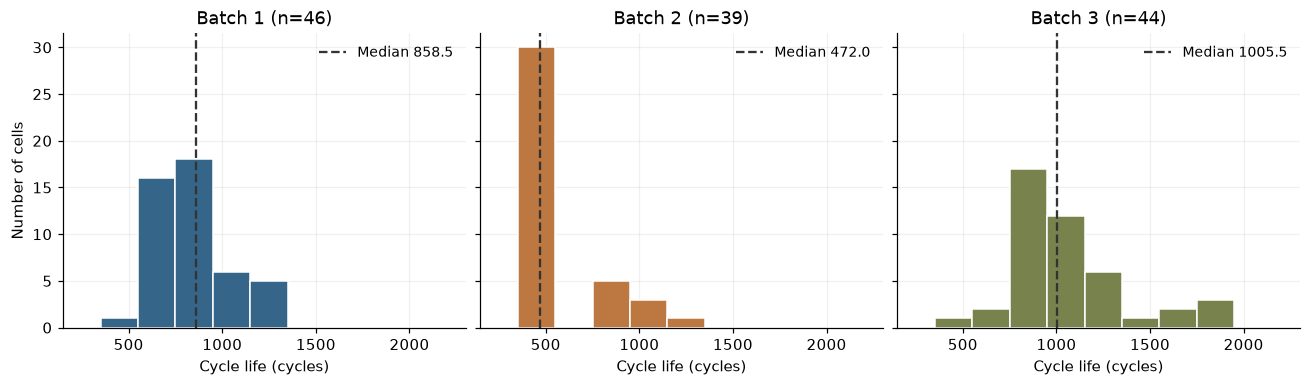

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.4), sharex=True, sharey=True, layout="constrained")
for ax, batch in zip(axes, BATCHES):
    life = valid.loc[valid["batch"].eq(batch), "cycle_life"]
    ax.hist(life, bins=np.arange(150, 2351, 200), color=COLORS[batch], edgecolor="white")
    ax.axvline(life.median(), color="#333333", linestyle="--", label=f"Median {life.median():.1f}")
    ax.set(title=f"{batch} (n={len(life)})", xlabel="Cycle life (cycles)", xlim=(150, 2300))
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("Number of cells")
save_figure(fig, "01_life_distribution.png")

In [9]:
shortest = valid.loc[valid["cycle_life"].idxmin()]
b1_original = valid.loc[valid["batch"].eq("Batch 1")]
display(Markdown(f"""
**확인한 점:** B2의 500사이클 미만 비율은 {life_summary.loc['Batch 2', 'short_pct']:.1f}%입니다.
가장 짧은 셀은 `{shortest['cell_id']}`이며, 수명 {shortest['cycle_life']:.0f}사이클과
0.88 Ah 미만 도달 시점 {shortest['first_cycle_below_0_88']:.0f}사이클이 일치합니다.
짧은 수명이라는 이유로 삭제하지 않습니다.

**모델 전략:** B1 분석군의 수명은 {b1['cycle_life'].min():.0f}~{b1['cycle_life'].max():.0f}사이클입니다.
학습 범위보다 짧은 수명에 대한 과대 예측을 확인할 예정입니다.
B1 전체를 550사이클 기준으로 나누면 {int(b1_original['cycle_life'].lt(550).sum())}개 대
{int(b1_original['cycle_life'].ge(550).sum())}개로 불균형합니다.
수명 자체를 숫자로 예측하는 회귀를 선택했습니다.
"""))


**확인한 점:** B2의 500사이클 미만 비율은 71.8%입니다.
가장 짧은 셀은 `b2c19`이며, 수명 392사이클과
0.88 Ah 미만 도달 시점 392사이클이 일치합니다.
짧은 수명이라는 이유로 삭제하지 않습니다.

**모델 전략:** B1 분석군의 수명은 534~1074사이클입니다.
학습 범위보다 짧은 수명에 대한 과대 예측을 확인할 예정입니다.
B1 전체를 550사이클 기준으로 나누면 1개 대
45개로 불균형합니다.
수명 자체를 숫자로 예측하는 회귀를 선택했습니다.


## EDA 2 | 방전 용량과 열화 곡선
### 질문 2) 배치별 열화 곡선과 기울기가 달라지는 구간

B1 분석군 36개와 B2·B3 유효 라벨 셀의 전체 기록을 확인합니다.
세 그래프는 같은 축 범위이며, 0.8~1.2 Ah 구간을 확대했습니다.
범위 밖 측정값을 삭제한 것은 아닙니다. 0 이하·비유한 용량만 그래프에서 결측으로 표시합니다.

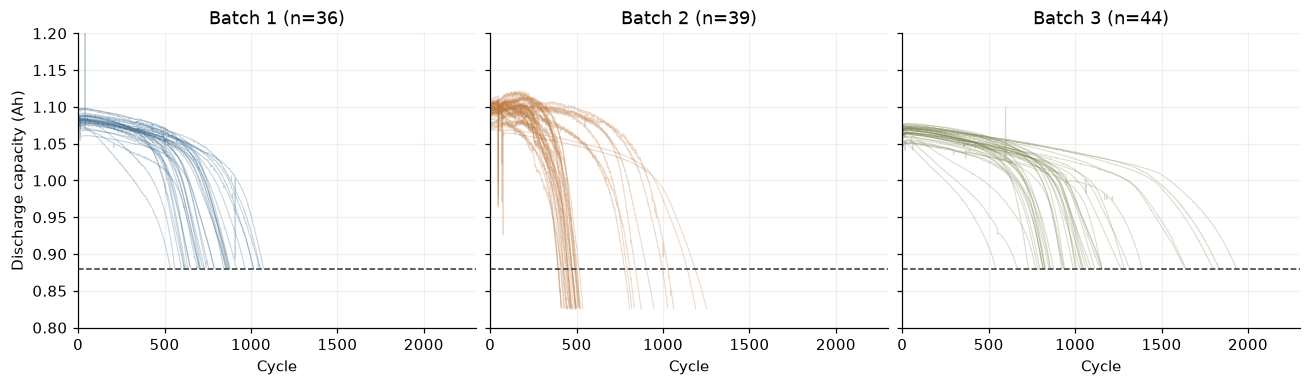

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.4), sharex=True, sharey=True, layout="constrained")
for ax, (batch, group) in zip(axes, cohorts.items()):
    for cell in group["cell_id"]:
        curve = capacity_curves[cell]
        qd = curve["qd"].copy()
        qd[~np.isfinite(qd) | (qd <= 0)] = np.nan
        ax.plot(curve["cycle"], qd, color=COLORS[batch], alpha=0.28, linewidth=0.7)
    ax.axhline(0.88, color="#333333", linestyle="--", linewidth=1)
    ax.set(title=f"{batch} (n={len(group)})", xlabel="Cycle", xlim=(0, 2300), ylim=(0.8, 1.2))
axes[0].set_ylabel("Discharge capacity (Ah)")
save_figure(fig, "02_capacity_curves.png")

### 대표 셀의 변화 후보 확인

배치별로 중앙 수명에 가장 가까운 셀을 선택합니다. 동률이면 셀 ID 문자열 순으로 선택합니다.
제공 수명까지의 `0 < QD < 1.5 Ah` 기록을 21개 관측치 이동중앙값으로 평활화한 뒤,
두 직선의 제곱오차 합이 가장 작은 분할점을 찾습니다.
각 구간에 유효 기록의 20%(최소 50개)를 남기며, 5개 기록 간격으로 탐색합니다.
이 용량 필터는 변화 후보 탐색용이며 초기 Feature 처리 기준과 구분합니다.

In [11]:
def fit_change_candidate(curve, life, fraction=0.20):
    """두 구간의 기울기가 달라지는 위치를 탐색합니다. 확정된 knee는 아닙니다."""
    cycle, qd = curve["cycle"], curve["qd"]
    keep = np.isfinite(cycle) & np.isfinite(qd) & (qd > 0) & (qd < 1.5) & (cycle <= life)
    x, y = cycle[keep], qd[keep]
    smooth = pd.Series(y).rolling(21, center=True, min_periods=1).median().to_numpy()
    margin = max(50, int(len(x) * fraction))
    candidates = list(range(margin, len(x) - margin, 5))
    if not candidates:
        raise ValueError("분할점을 비교하기에 유효 기록이 부족합니다.")
    best = None
    for index in candidates:
        before = np.polyfit(x[:index], smooth[:index], 1)
        after = np.polyfit(x[index:], smooth[index:], 1)
        error = (np.square(smooth[:index] - np.polyval(before, x[:index])).sum()
                 + np.square(smooth[index:] - np.polyval(after, x[index:])).sum())
        if best is None or error < best[0]:
            best = (error, index, before, after)
    _, index, before, after = best
    result = {"candidate_cycle": x[index], "slope_before": before[0], "slope_after": after[0],
              "at_search_boundary": index in (candidates[0], candidates[-1]), "n_used": len(x)}
    return result, (x, y, smooth)

representatives, fitted_curves = [], {}
for batch, group in cohorts.items():
    ordered = group.assign(distance=(group["cycle_life"] - group["cycle_life"].median()).abs())
    row = ordered.sort_values(["distance", "cell_id"], kind="stable").iloc[0]
    result, fitted = fit_change_candidate(capacity_curves[row["cell_id"]], row["cycle_life"])
    representatives.append({"batch": batch, "cell_id": row["cell_id"], "life": row["cycle_life"], **result})
    fitted_curves[batch] = fitted
knee_summary = pd.DataFrame(representatives)
display(knee_summary)

,batch,cell_id,life,candidate_cycle,slope_before,slope_after,at_search_boundary,n_used
0,Batch 1,b1c11,788.0,594.0,-6.226e-05,-7.176e-04,False,786
1,Batch 2,b2c16,472.0,335.0,-1.468e-04,-1.113e-03,False,472
2,Batch 3,b3c0,1009.0,807.0,-5.803e-05,-6.747e-04,True,1008


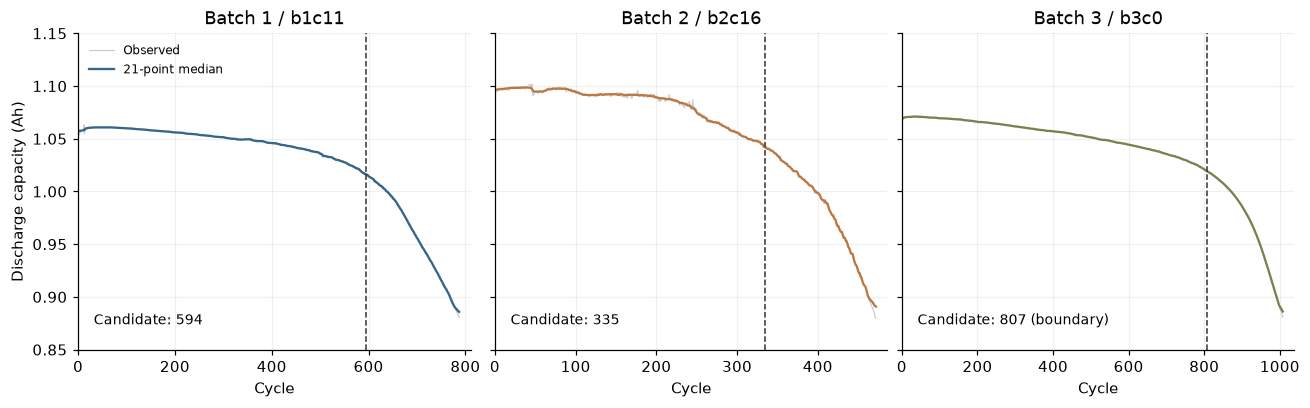

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.6), sharey=True, layout="constrained")
for ax, row in zip(axes, knee_summary.itertuples(index=False)):
    x, y, smooth = fitted_curves[row.batch]
    ax.plot(x, y, color="#C7CDD2", linewidth=0.8, label="Observed")
    ax.plot(x, smooth, color=COLORS[row.batch], linewidth=1.5, label="21-point median")
    ax.axvline(row.candidate_cycle, color="#333333", linestyle="--", linewidth=1)
    boundary_note = " (boundary)" if row.at_search_boundary else ""
    ax.text(0.04, 0.08, f"Candidate: {row.candidate_cycle:.0f}{boundary_note}", transform=ax.transAxes, fontsize=9)
    ax.set(title=f"{row.batch} / {row.cell_id}", xlabel="Cycle", ylim=(0.85, 1.15), xlim=(0, x[-1] * 1.03))
axes[0].set_ylabel("Discharge capacity (Ah)")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
save_figure(fig, "03_change_candidates.png")

**확인한 점:** 세 대표 셀에서 후반 용량 감소가 더 빨랐습니다. 변화 후보는 594·335·807사이클입니다.
B3의 후보는 탐색 범위 끝에 있어 설정에 민감합니다. 배치당 한 셀의 예시이므로 공통 knee로 단정하지 않습니다.

**모델 전략:** 초기 용량 변화량과 기울기를 후보로 사용합니다.
전체 수명 곡선과 위 변화 후보는 100사이클 이후 정보가 포함되므로 입력에서 제외합니다.

## EDA 3 | 초기 방전 곡선의 차이
### 질문 3) ΔQ(V) 곡선과 수명의 관계

동일 전압에서 **ΔQ(V) = Qd,100(V) − Qd,10(V)**를 계산합니다.
각 배치의 수명 하위·상위 25% 그룹을 비교하며, 경계에서 수명이 같은 셀은 모두 포함합니다.
앞의 500·1,000사이클 절대 기준과는 다른 상대적인 구분입니다.

In [13]:
def pair_statistics(table, x, y):
    """결측이 없는 동일한 쌍으로 상관계수와 표본 수를 계산합니다."""
    pair = table[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(pair) < 3 or pair[x].nunique() < 2 or pair[y].nunique() < 2:
        return {"n": len(pair), "pearson": np.nan, "spearman": np.nan}
    return {"n": len(pair), "pearson": pair[x].corr(pair[y]),
            "spearman": pair[x].corr(pair[y], method="spearman")}

delta_rows = []
for batch, group in cohorts.items():
    q25, q75 = group["cycle_life"].quantile([0.25, 0.75])
    delta_rows.append({
        "batch": batch, "q25": q25, "low_n": int(group["cycle_life"].le(q25).sum()),
        "q75": q75, "high_n": int(group["cycle_life"].ge(q75).sum()),
        **pair_statistics(group, "dq_log10_variance", "cycle_life"),
    })
delta_summary = pd.DataFrame(delta_rows).set_index("batch")
display(delta_summary.round(3))
grid = next(iter(delta_curves.values()))["voltage"]
print(f"공통 전압 격자: {len(grid):,}점 / {grid.min():.1f}~{grid.max():.1f} V / {len(delta_curves)}개 셀")

,q25,low_n,q75,high_n,n,pearson,spearman
batch,,,,,,,
Batch 1,681.0,9,871.50,9,36,-0.827,-0.826
Batch 2,439.5,10,508.50,10,39,-0.902,-0.709
Batch 3,828.0,12,1155.25,11,44,-0.702,-0.797


공통 전압 격자: 1,000점 / 2.0~3.5 V / 119개 셀


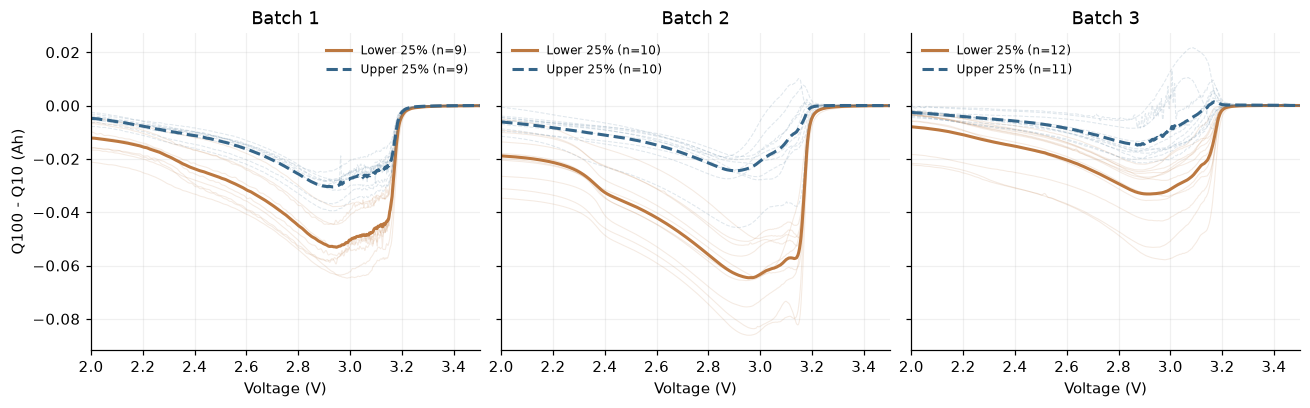

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.6), sharex=True, sharey=True, layout="constrained")
for ax, (batch, group) in zip(axes, cohorts.items()):
    thresholds = delta_summary.loc[batch]
    groups = [
        (group.loc[group["cycle_life"].le(thresholds["q25"])], "#BC7840", "Lower 25%", "-"),
        (group.loc[group["cycle_life"].ge(thresholds["q75"])], "#356589", "Upper 25%", "--"),
    ]
    for selected, color, label, linestyle in groups:
        values = np.stack([delta_curves[cell]["delta_q"] for cell in selected["cell_id"]])
        for delta in values:
            ax.plot(grid, delta, color=color, alpha=0.15, linewidth=0.7, linestyle=linestyle)
        ax.plot(grid, values.mean(axis=0), color=color, linewidth=2, linestyle=linestyle,
                label=f"{label} (n={len(selected)})")
    ax.set(title=batch, xlabel="Voltage (V)", xlim=(2.0, 3.5))
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("Q100 - Q10 (Ah)")
save_figure(fig, "04_delta_q_curves.png")

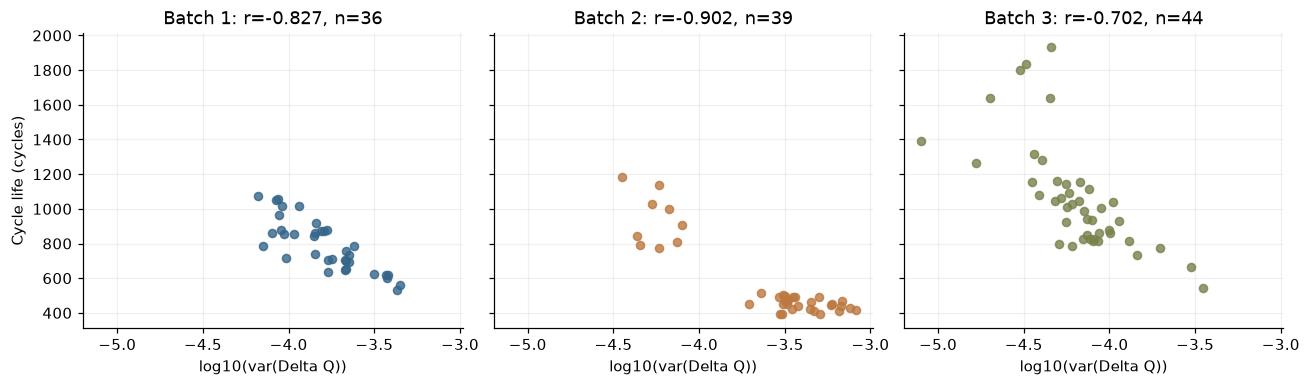

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.4), sharex=True, sharey=True, layout="constrained")
for ax, (batch, group) in zip(axes, cohorts.items()):
    ax.scatter(group["dq_log10_variance"], group["cycle_life"], color=COLORS[batch], s=28, alpha=0.8)
    stats = delta_summary.loc[batch]
    ax.set(title=f"{batch}: r={stats['pearson']:.3f}, n={int(stats['n'])}", xlabel="log10(var(Delta Q))")
axes[0].set_ylabel("Cycle life (cycles)")
save_figure(fig, "05_delta_q_life.png")

가는 선은 개별 셀, 굵은 선은 그룹 평균입니다. 분산은 각 셀의 1,000개 전압 지점에서
`np.var(delta_q, ddof=0)`으로 계산한 뒤 `log10`을 취합니다. 0분산이나 결측을 임의 대체하지 않습니다.

**확인한 점:** 세 배치 모두 ΔQ 로그분산과 수명이 음의 관계를 보입니다.
낮은 수명 그룹의 평균 곡선은 약 2.9~3.0 V에서 더 크게 내려갑니다.

**모델 전략:** ΔQ 로그분산 하나로 시작하고, 다른 Feature의 추가 효과를 B1에서 비교할 예정입니다.
상관계수는 예측 정확도가 아니며, B2·B3의 상관을 기준으로 모델을 조정하지 않습니다.

## EDA 4 | 충전 조건과 배터리 수명
### 질문 4) 정책별 평균 수명과 초기 용량 기울기 비교

정책은 `C1(전환 SOC)-C2` 형식입니다. C1·C2는 전환 전·후 충전 속도이며 SOC는 전환 시 충전 비율입니다.
정책의 `newstructure` 접미사는 서로 다른 기록 조건일 수 있어 유지합니다.

In [16]:
policy_summary = analysis.groupby(["batch", "policy_group"]).agg(
    n=("cell_id", "size"), mean_life=("cycle_life", "mean"),
    min_life=("cycle_life", "min"), max_life=("cycle_life", "max"),
    mean_early_slope=("QDischarge_slope_2_100", "mean"),
).reset_index()
extremes = []
for batch, group in policy_summary.groupby("batch", sort=True):
    ordered = group.sort_values(["mean_life", "policy_group"])
    extremes.append(ordered.iloc[[0, -1]].assign(position=["평균 수명 최소", "평균 수명 최대"]))
policy_extremes = pd.concat(extremes, ignore_index=True)
display(policy_extremes[["batch", "position", "policy_group", "n", "mean_life"]])
display(policy_summary.groupby("batch").size().rename("정책 수").to_frame())

,batch,position,policy_group,n,mean_life
0,Batch 1,평균 수명 최소,5.4C(80%)-5.4C,2,546.500
1,Batch 1,평균 수명 최대,4.4C(80%)-4.4C,1,1074.000
2,Batch 2,평균 수명 최소,3.6C(9%)-5C,2,394.500
3,Batch 2,평균 수명 최대,5.6C(26%)-4.5C-newstructure,3,991.333
4,Batch 3,평균 수명 최소,3.7C(31%)-5.9C-newstructure,3,660.000
5,Batch 3,평균 수명 최대,4.8C(80%)-4.8C-newstructure,6,1564.167


,정책 수
batch,
Batch 1,20
Batch 2,12
Batch 3,8


### C1·전환 SOC·C2와 초기 기울기

기울기는 2~100사이클의 유효 용량에 직선을 맞춘 값(Ah/사이클)입니다.
작을수록 용량이 덜 늘거나 더 감소했다는 뜻이며, 초기부터 모든 셀의 용량이 감소하는 것은 아닙니다.

,batch,feature,n,pearson,spearman
0,Batch 1,C1_rate,36,-0.016,-0.232
1,Batch 1,switch_soc_pct,36,-0.289,-0.063
2,Batch 1,C2_rate,36,-0.562,-0.168
3,Batch 2,C1_rate,39,0.114,-0.070
4,Batch 2,switch_soc_pct,39,0.087,0.017
5,Batch 2,C2_rate,39,-0.337,-0.134
6,Batch 3,C1_rate,44,0.718,-0.093
7,Batch 3,switch_soc_pct,44,0.264,0.384
8,Batch 3,C2_rate,44,-0.708,-0.199


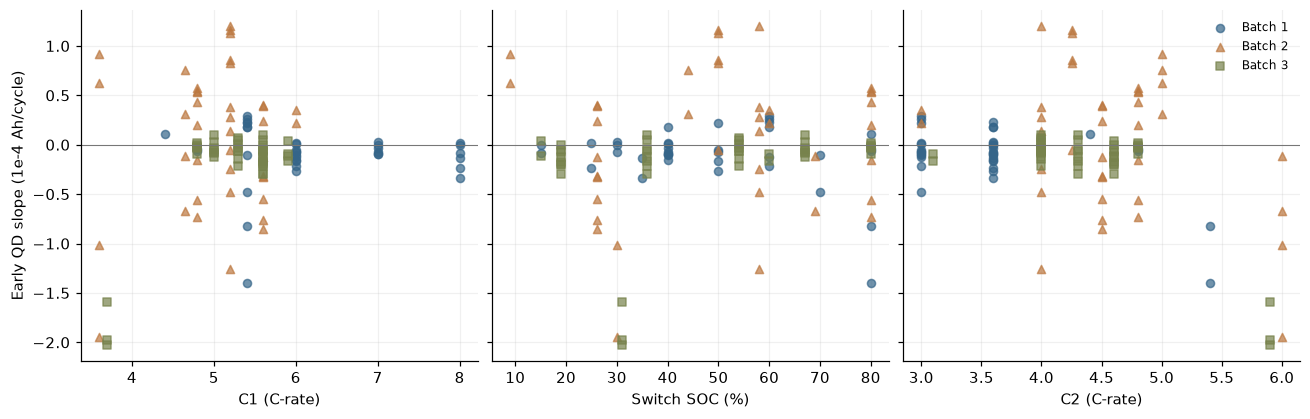

In [17]:
policy_columns = {"C1_rate": "C1 (C-rate)", "switch_soc_pct": "Switch SOC (%)", "C2_rate": "C2 (C-rate)"}
policy_correlations = pd.DataFrame([
    {"batch": batch, "feature": column, **pair_statistics(group, column, "QDischarge_slope_2_100")}
    for batch, group in cohorts.items() for column in policy_columns
])
display(policy_correlations.round(3))

fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.7), sharey=True, layout="constrained")
for ax, (column, label) in zip(axes, policy_columns.items()):
    for batch, group in cohorts.items():
        ax.scatter(group[column], group["QDischarge_slope_2_100"] * 10000,
                   color=COLORS[batch], marker=MARKERS[batch], s=28, alpha=0.7, label=batch)
    ax.axhline(0, color="#777777", linewidth=0.7)
    ax.set(xlabel=label)
axes[0].set_ylabel("Early QD slope (1e-4 Ah/cycle)")
axes[-1].legend(frameon=False, fontsize=8)
save_figure(fig, "06_policy_and_early_slope.png")

In [18]:
soc_comparison = b1.loc[b1["C1_rate"].eq(8) & b1["C2_rate"].eq(3.6)].groupby("switch_soc_pct").agg(
    n=("cell_id", "size"), mean_life=("cycle_life", "mean"),
)
display(soc_comparison)

,n,mean_life
switch_soc_pct,,
15.0,2,1008.5
25.0,2,676.5
35.0,2,607.5


**확인한 점:** B1에서 C1=8C·C2=3.6C가 같아도 SOC 15%와 35%의 평균 수명은 달랐습니다.
각 2개뿐이므로 인과 효과로 단정하기 어렵습니다. C2와 초기 기울기는 세 배치 모두 음의 Pearson 관계지만,
순위 상관은 약해 일부 값의 영향도 확인해야 합니다.

**모델 전략:** C1·전환 SOC·C2를 함께 보조 Feature로 비교할 예정입니다.
같은 정책을 외우는 효과를 줄이기 위해 정책 그룹을 나누어 학습·검증을 진행할 예정입니다.

## EDA 5 | Feature 상관관계 분석
### 질문 5) 수명과의 상관관계와 중복 정보 확인

B1 분석군을 중심으로 Pearson 상관을 확인합니다. 아래 표에서는 배치별 차이와 유효 쌍의 수를 함께 표시합니다.
`Tmax mean`은 각 사이클 최고 온도를 초기 구간에서 평균한 값입니다.

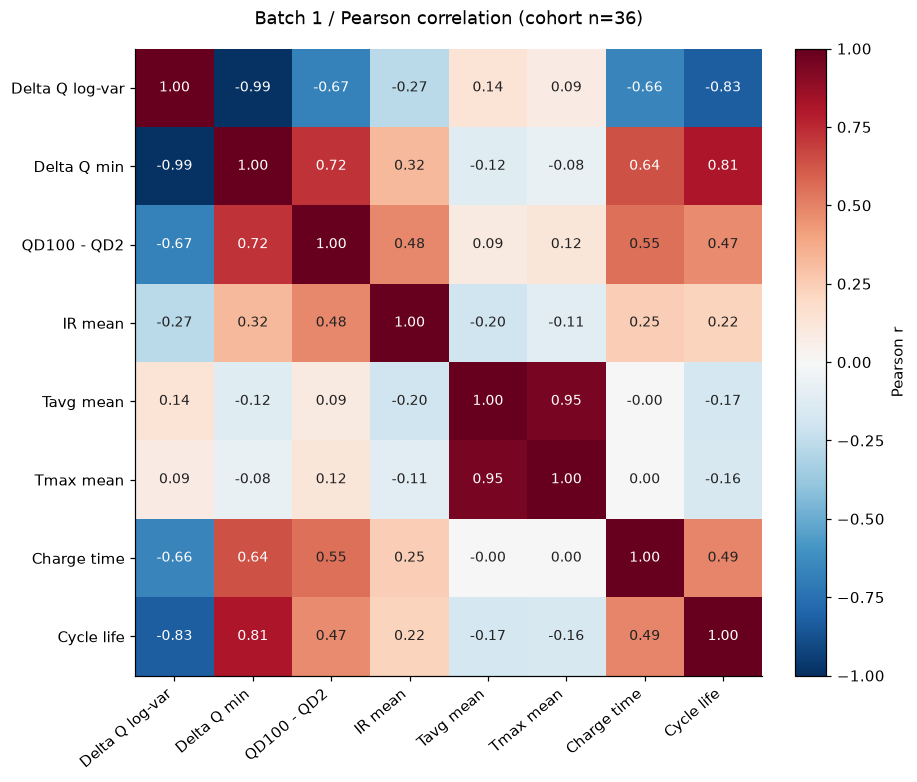

In [19]:
heatmap_columns = {
    "dq_log10_variance": "Delta Q log-var", "dq_min_Ah": "Delta Q min",
    "QDischarge_delta_100_2": "QD100 - QD2", "IR_mean_2_100": "IR mean",
    "Tavg_mean_2_100": "Tavg mean", "Tmax_mean_2_100": "Tmax mean",
    "chargetime_mean_2_100": "Charge time", "cycle_life": "Cycle life",
}
correlation_matrix = b1[list(heatmap_columns)].corr(min_periods=3)
present = b1[list(heatmap_columns)].notna().astype(int)
pair_counts = present.T.dot(present)

fig, ax = plt.subplots(figsize=(8.8, 7.0), layout="constrained")
im = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap="RdBu_r", aspect="equal")
labels = list(heatmap_columns.values())
ax.set_xticks(range(len(labels)), labels, rotation=40, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.grid(False)
for i in range(len(labels)):
    for j in range(len(labels)):
        value = correlation_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(value) > 0.6 else "#222222")
ax.set_title(f"Batch 1 / Pearson correlation (cohort n={len(b1)})", pad=16)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
save_figure(fig, "07_feature_correlations.png")

In [20]:
correlation_pairs = [
    ("ΔQ 로그분산 - 수명", "dq_log10_variance", "cycle_life"),
    ("평균 충전 시간 - 수명", "chargetime_mean_2_100", "cycle_life"),
    ("평균 온도 - 수명", "Tavg_mean_2_100", "cycle_life"),
    ("평균 온도 - 최고 온도", "Tavg_mean_2_100", "Tmax_mean_2_100"),
    ("ΔQ 로그분산 - ΔQ 최솟값", "dq_log10_variance", "dq_min_Ah"),
]
correlation_rows = pd.DataFrame([
    {"pair": label, "batch": batch, **pair_statistics(group, x, y)}
    for label, x, y in correlation_pairs for batch, group in cohorts.items()
])
display(correlation_rows.pivot(index="pair", columns="batch", values="pearson").round(3))
display(correlation_rows.pivot(index="pair", columns="batch", values="n").rename_axis("유효 쌍의 수"))

batch,Batch 1,Batch 2,Batch 3
pair,,,
ΔQ 로그분산 - ΔQ 최솟값,-0.988,-0.975,-0.921
ΔQ 로그분산 - 수명,-0.827,-0.902,-0.702
평균 온도 - 수명,-0.173,0.425,-0.022
평균 온도 - 최고 온도,0.953,0.825,0.971
평균 충전 시간 - 수명,0.490,0.087,0.637


batch,Batch 1,Batch 2,Batch 3
유효 쌍의 수,,,
ΔQ 로그분산 - ΔQ 최솟값,36,39,44
ΔQ 로그분산 - 수명,36,39,44
평균 온도 - 수명,36,39,44
평균 온도 - 최고 온도,36,39,44
평균 충전 시간 - 수명,36,39,44


### 큰 충전 시간 기록의 영향

B2의 초기 구간에는 약 3,933분 기록이 포함되어 있습니다.
같은 39개 셀에서 원래 평균, 중앙값, 100분 초과 기록만 제외한 평균을 비교합니다.
마지막 방법은 민감도 분석이며 기본 Feature를 바꾸거나 셀을 삭제하지 않습니다.

In [21]:
analysis_long_charges = long_charges.loc[long_charges["cell_id"].isin(analysis["cell_id"])]
display(analysis_long_charges.loc[analysis_long_charges["batch"].eq("Batch 2")].reset_index(drop=True))
charge_methods = {
    "chargetime_mean_2_100": "Mean (all records)",
    "chargetime_median_2_100": "Median (all records)",
    "chargetime_mean_le100": "Mean (records <=100 min)",
}
charge_sensitivity = pd.DataFrame([
    {"batch": batch, "method": label, **pair_statistics(group, column, "cycle_life")}
    for batch, group in cohorts.items() for column, label in charge_methods.items()
])
display(charge_sensitivity.round(3))

,batch,cell_id,cycle,minutes
0,Batch 2,b2c14,50,3934.705
1,Batch 2,b2c20,50,3932.593
2,Batch 2,b2c26,51,3933.121
3,Batch 2,b2c28,49,3933.736
4,Batch 2,b2c30,52,3933.401
5,Batch 2,b2c32,71,3933.455
6,Batch 2,b2c34,77,3934.124
7,Batch 2,b2c41,51,3933.623
8,Batch 2,b2c44,70,3932.507
9,Batch 2,b2c46,48,3933.840


,batch,method,n,pearson,spearman
0,Batch 1,Mean (all records),36,0.490,0.477
1,Batch 1,Median (all records),36,0.571,0.461
2,Batch 1,Mean (records <=100 min),36,0.570,0.426
3,Batch 2,Mean (all records),39,0.087,-0.393
4,Batch 2,Median (all records),39,-0.918,-0.812
5,Batch 2,Mean (records <=100 min),39,-0.917,-0.756
6,Batch 3,Mean (all records),44,0.637,0.192
7,Batch 3,Median (all records),44,0.638,0.261
8,Batch 3,Mean (records <=100 min),44,0.637,0.192


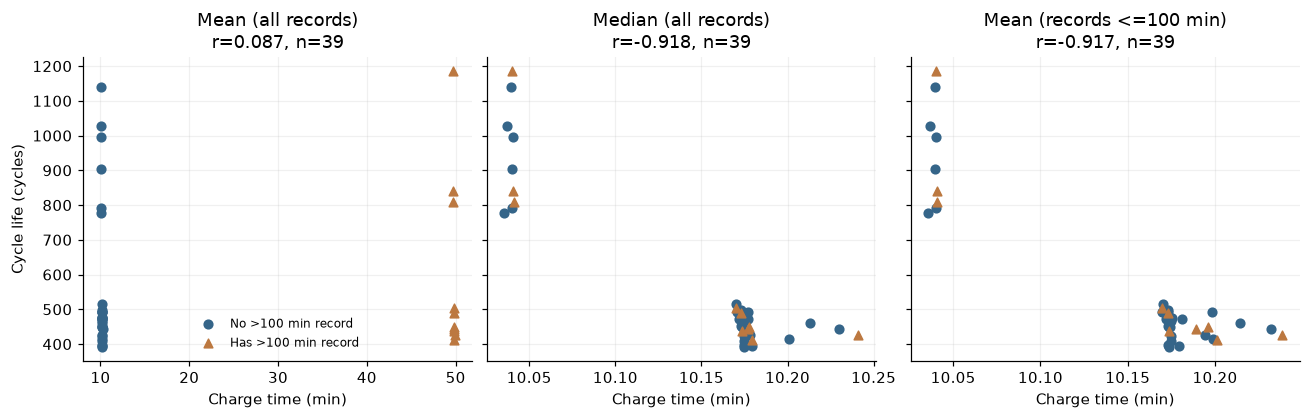

In [22]:
b2 = cohorts["Batch 2"]
fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.7), sharey=True, layout="constrained")
has_long_record = b2["chargetime_gt100_n"].gt(0)
for ax, (column, label) in zip(axes, charge_methods.items()):
    for mask, marker, color, legend in [
        (~has_long_record, "o", "#356589", "No >100 min record"),
        (has_long_record, "^", "#BC7840", "Has >100 min record"),
    ]:
        selected = b2.loc[mask]
        ax.scatter(selected[column], selected["cycle_life"], marker=marker, color=color, s=32, label=legend)
    stats = pair_statistics(b2, column, "cycle_life")
    ax.set(title=f"{label}\nr={stats['pearson']:.3f}, n={stats['n']}", xlabel="Charge time (min)")
axes[0].set_ylabel("Cycle life (cycles)")
axes[0].legend(frameon=False, fontsize=8)
save_figure(fig, "08_charge_time_sensitivity.png")

**확인한 점:** B1에서는 평균·최고 온도, ΔQ 로그분산·최솟값의 중복이 큽니다.
B2의 충전 시간과 수명 상관은 원래 평균 0.087, 중앙값 −0.918,
100분 초과 기록 제외 평균 −0.917로 크게 달라집니다. 큰 값의 영향이 있으나 오류로 확정한 것은 아닙니다.

**모델 전략:** 중복 정보가 큰 Feature는 하나씩 비교하고 Ridge도 후보로 둡니다.
충전 시간의 평균·중앙값은 B1 학습 부분의 CV로 비교하며,
B2에서 상관이 커진다는 이유로 처리 기준을 바꾸지 않습니다.

## 설계 | Feature와 모델 선택

EDA에서 확인한 근거를 바탕으로 적은 Feature부터 비교합니다.
이 단계의 설계는 아래 표로 정리하며, 실제 학습과 성능 결과는 `2_ESS-Life.ipynb`에서 확인합니다.

| 순서 | Feature 구성 | 근거 |
|---|---|---|
| 1 | ΔQ 로그분산 | 세 배치에서 수명과 음의 관계입니다. |
| 2 | 용량 변화량·충전 시간 추가 | 초기 변화와 충전 특성을 반영합니다. 평균·중앙값을 각각 비교합니다. |
| 3 | 평균 온도·C1·SOC·C2 추가 | 중복 온도는 줄이고 충전 조건은 묶어서 비교합니다. |
| 4 | 용량 기울기·IR 추가 | 결측과 노이즈를 확인한 뒤 추가 효과를 비교합니다. |

| 후보 모델 | 비교 이유 |
|---|---|
| Linear Regression | 적은 Feature의 선형 관계를 기준으로 확인합니다. |
| Ridge | Feature 간 중복의 영향을 규제로 조절합니다. |
| Random Forest | 비선형 관계와 짧은 수명의 과대 예측을 확인합니다. |
| SVR (RBF) | 표준화한 Feature로 곡선 관계를 비교합니다. |

**입력에서 제외할 정보:** 수명 정답, 마지막 용량, 전체 기록 길이, 100사이클 이후 값,
전체 수명에서 구한 변화 후보, 배치 번호와 셀 ID입니다. `analysis` 표 전체를 모델 입력에 넣지 않습니다.

## 검증 | 데이터 분할 및 성능 평가 계획

- B1 분석군에서 정책 그룹을 유지하며 약 20%를 hold-out으로 분리할 예정입니다(`random_state=42`).
- 나머지 학습 부분에서 정책 그룹을 유지한 5-fold CV로 Feature와 설정을 선택할 예정입니다.
  결측 대체와 표준화도 각 학습 fold 안에서 진행할 예정입니다.
- 설정을 고정한 후 hold-out을 확인하고, B1 분석군 전체로 재학습하여 B2에서 평가할 예정입니다.
  B3 모델 평가는 선택 사항입니다.
- MAPE(%)와 MAE(사이클)를 기록할 예정입니다. Gap은 `CV−hold-out`, `hold-out−B2`,
  `9.1−B2` 순서의 차이(%p)이며, 음수이면 뒤쪽 오차가 더 크다는 뜻입니다.
- 작은 표본과 라벨·분포 차이가 있어 Gap만으로 과적합을 단정하지 않을 예정입니다.

**분석의 한계:** B1의 마지막 용량으로 정한 분석군에는 표본 선택 편향이 있습니다.
B2·B3의 분포와 수명 관계도 미리 살펴보았으므로 완전히 미확인인 독립 시험으로 보기는 어렵습니다.
이후 모델 선택은 B1에서만 진행하며, 성능을 보고 셀을 사후 삭제하지 않습니다.

**ESS 활용 방향:** 수명 예측은 추가 점검과 교체 계획을 검토하는 자료로 활용할 수 있습니다.
총 수명을 예측하는 분석이며, 실시간 잔여 수명이나 안전 이상 발생 확률을 예측하는 모델은 아닙니다.

## 저장 | 계산 결과와 재현 확인

핵심 계산이 보고서의 수치와 맞는지 확인합니다. 이 검사는 현재 원본 파일에 대한 재현 점검이며,
다른 데이터로 바꾸면 분석 기준과 함께 다시 확인해야 합니다.

In [23]:
assert cohort_counts["raw_cells"].tolist() == [46, 47, 46]
assert cohort_counts["valid_labels"].tolist() == [46, 39, 44]
assert cohort_counts["analysis_cells"].tolist() == [36, 39, 44]
assert features["cell_id"].is_unique
assert analysis["early_100_coverage"].all()
assert len(grid) == 1000 and np.allclose([grid.min(), grid.max()], [2.0, 3.5])
assert np.allclose(life_summary["median"], [858.5, 472.0, 1005.5])
assert np.allclose(delta_summary["pearson"], [-0.827, -0.902, -0.702], atol=0.001)
assert knee_summary["candidate_cycle"].tolist() == [594, 335, 807]
assert knee_summary.loc[knee_summary["batch"].eq("Batch 3"), "at_search_boundary"].all()
assert analysis_long_charges["batch"].eq("Batch 2").sum() == 10

# 모델용 Feature와 곡선에서 직접 계산한 값이 같은지 확인합니다.
for row in analysis.itertuples(index=False):
    variance = np.var(delta_curves[row.cell_id]["delta_q"], ddof=0)
    assert np.isclose(np.log10(variance), row.dq_log10_variance)
assert not {"cycle_life", "last_qd", "record_count", "cell_id", "batch"}.intersection(FEATURE_COLUMNS)
print("분석군, 곡선 격자, 핵심 수치와 Feature 계산을 확인했습니다.")

분석군, 곡선 격자, 핵심 수치와 Feature 계산을 확인했습니다.


In [24]:
tables = {
    "source_files.csv": source_files.drop(columns="exists"),
    "cohort_counts.csv": cohort_counts.reset_index(),
    "feature_audit.csv": features,
    "analysis_features.csv": analysis,
    "excluded_cells.csv": excluded_cells,
    "quality_summary.csv": quality_summary.reset_index(),
    "label_checks.csv": label_summary.reset_index(),
    "life_distribution.csv": life_summary.reset_index(),
    "change_candidates.csv": knee_summary,
    "delta_q_summary.csv": delta_summary.reset_index(),
    "policy_summary.csv": policy_summary,
    "policy_correlations.csv": policy_correlations,
    "correlation_comparison.csv": correlation_rows,
    "correlation_matrix_b1.csv": correlation_matrix.rename_axis("feature").reset_index(),
    "correlation_pair_counts_b1.csv": pair_counts.rename_axis("feature").reset_index(),
    "charge_time_records_gt100.csv": long_charges,
    "charge_time_sensitivity.csv": charge_sensitivity,
}
for filename, table in tables.items():
    table.to_csv(OUTPUT_DIR / filename, index=False, encoding="utf-8-sig")
print(f"results/eda에 표 {len(tables)}개와 그림 8개를 저장했습니다.")

results/eda에 표 17개와 그림 8개를 저장했습니다.
